In [ ]:
#in this code I devided frp data to 3 categories: if frps3a and frps3b are nan->0 elif frps3a or frps3b is nan return not nan else: return average data
#this data comes from Sentinel
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Open datasets
gfas_fire_xr = xr.open_mfdataset('/lustre/ARUN/user/thunthita/FRP/*-C3S-L3-FRP-SLSTR-P1D-0.1deg-fv1.0.nc', combine='by_coords', engine='netcdf4')
ffmc_dataset = xr.open_mfdataset('/lustre/ARUN/user/thunthita/FWI/ECMWF_FWI_FFMC_*_1200_hr_v4.0_con.nc', combine='by_coords', engine='netcdf4')
fwi_dataset = xr.open_mfdataset('/lustre/ARUN/user/thunthita/FWI/ECMWF_FWI_FWI_*_1200_hr_v4.0_con.nc', combine='by_coords', engine='netcdf4')

# Define a function to set time to 00:00:00
def set_time_to_midnight(ds):
    ds['time'] = pd.to_datetime(ds['time'].dt.floor('D'))
    return ds

# Apply the function to each dataset
gfas_fire_xr = set_time_to_midnight(gfas_fire_xr)
ffmc_dataset = set_time_to_midnight(ffmc_dataset)
fwi_dataset = set_time_to_midnight(fwi_dataset)

# Subset data to match the time range of FRP data
time_range = slice('2020-03-01', '2021-02-28')
ffmc = ffmc_dataset.sel(time=time_range)
fwi = fwi_dataset.sel(time=time_range)
frps3a = gfas_fire_xr['s3a_night_frp'].sel(time=time_range)
uncfrps3a = gfas_fire_xr['s3a_night_frp_unc'].sel(time=time_range)
frps3b = gfas_fire_xr['s3b_night_frp'].sel(time=time_range)
uncfrps3b = gfas_fire_xr['s3b_night_frp_unc'].sel(time=time_range)
fires3a = gfas_fire_xr['s3a_night_fire'].sel(time=time_range)
fires3b = gfas_fire_xr['s3b_night_fire'].sel(time=time_range)

fires3a = fires3a.astype(float)
fires3b = fires3b.astype(float)

# Select subsets
subset_ffmc = ffmc.sel(latitude=slice(20.5, 5.5), longitude=slice(97.5, 105.5))
subset_fwi = fwi.sel(latitude=slice(20.5, 5.5), longitude=slice(97.5, 105.5))
subset_frps3a = frps3a.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5))
subset_uncfrps3a = uncfrps3a.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5))
subset_frps3b = frps3b.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5))
subset_uncfrps3b = uncfrps3b.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5))
subset_fires3a = fires3a.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5))
subset_fires3b = fires3b.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5))

# Combine FRP values respecting NaN conditions
frp_combined = xr.where(
    subset_frps3a.notnull() & subset_frps3b.isnull(),  # Only frp3a is not NaN
    subset_frps3a,                             # Take frp3a
    xr.where(
        subset_frps3a.isnull() & subset_frps3b.notnull(),  # Only frp3b is not NaN
        subset_frps3b,                           # Take frp3b
        xr.where(
            subset_frps3a.notnull() & subset_frps3b.notnull(),   # Both frp3a and frp3b are not NaN
            (subset_frps3a + subset_frps3b) / 2,                 # Average of frp3a and frp3b
            0                                    # Both are NaN, return 0
        )
    )
)

uncfrp_combined = xr.where(
    subset_uncfrps3a.notnull() & subset_uncfrps3b.isnull(),  # Only frp3a is not NaN
    subset_uncfrps3a,                             # Take frp3a
    xr.where(
        subset_uncfrps3a.isnull() & subset_uncfrps3b.notnull(),  # Only frp3b is not NaN
        subset_uncfrps3b,                           # Take frp3b
        xr.where(
            subset_uncfrps3a.notnull() & subset_uncfrps3b.notnull(),   # Both frp3a and frp3b are not NaN
            (subset_uncfrps3a + subset_uncfrps3b) ,                 # Average of frp3a and frp3b
            0                                    # Both are NaN, return 0
        )
    )
)

# Combine fire values respecting NaN conditions
fire_combined = xr.where(
    subset_fires3a.notnull() & subset_fires3b.isnull(),  # Only fires3a is not NaN
    subset_fires3a,                               # Take fires3a
    xr.where(
        subset_fires3a.isnull() & subset_fires3b.notnull(),  # Only fires3b is not NaN
        subset_fires3b,                             # Take fires3b
        xr.where(
            subset_fires3a.notnull() & subset_fires3b.notnull(),   # Both fires3a and fires3b are not NaN
            (subset_fires3a + subset_fires3b) / 2,                 # Average of fires3a and fires3b
            0                                        # Both are NaN, return 0
        )
    )
)

# Compute means
mean_ffmc = subset_ffmc.mean(dim=['latitude', 'longitude'])
mean_fwi = subset_fwi.mean(dim=['latitude', 'longitude'])
mean_frp = frp_combined.mean(dim=['lat', 'lon'])
mean_fire = fire_combined.mean(dim=['lat', 'lon'])
mean_uncfrp = uncfrp_combined.mean(dim=['lat', 'lon'])

# Output the mean_ffmc value
print(mean_ffmc)


In [2]:
sum_fire = fire_combined.sum(dim=['lat', 'lon'])
sum_fire

<xarray.DataArray (time: 365)> Size: 3kB
dask.array<sum-aggregate, shape=(365,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-03-01 2020-03-02 ... 2021-02-28

In [3]:
gfas_fire_xr

<xarray.Dataset> Size: 227GB
Dimensions:                                           (time: 365, lon: 3600,
                                                       bounds: 2, lat: 1800)
Coordinates:
  * lon                                               (lon) float32 14kB -179...
  * lat                                               (lat) float32 7kB 89.95...
  * time                                              (time) datetime64[ns] 3kB ...
Dimensions without coordinates: bounds
Data variables: (12/19)
    lon_bounds                                        (time, lon, bounds) float32 11MB dask.array<chunksize=(1, 3600, 2), meta=np.ndarray>
    lat_bounds                                        (time, lat, bounds) float32 5MB dask.array<chunksize=(1, 1800, 2), meta=np.ndarray>
    time_bounds                                       (time, bounds) datetime64[ns] 6kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    s3a_night_fire                                    (time, lat, lon) float64 19GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
    s3a_night_frp                                     (time, lat, lon) float32 9GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
    s3a_night_frp_unc                                 (time, lat, lon) float32 9GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
    ...                                                ...
    s3b_night_FRP_related_surface_conditions_flag     (time, lat, lon) float64 19GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
    s3b_night_FRP_related_atmospheric_condition_flag  (time, lat, lon) float64 19GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
    s3a_night_related_atmospheric_condition_fraction  (time, lat, lon) float32 9GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
    s3b_night_related_atmospheric_condition_fraction  (time, lat, lon) float32 9GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
    s3a_night_fire_weighted                           (time, lat, lon) float32 9GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
    s3b_night_fire_weighted                           (time, lat, lon) float32 9GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
Attributes: (12/39)
    title:                      ECMWF C3S Gridded OLCI Fire Radiative Power p...
    institution:                King's College London, Brockmann Consult GmbH
    source:                     ESA Sentinel-3 A+B SLSTR FRP
    history:                    Created on 20210325T065258Z
    references:                 See https://climate.copernicus.eu/
    tracking_id:                c7854f27-0c49-48f4-a17b-8b0c948ae900
    ...                         ...
    sensor:                     SLSTR
    spatial_resolution:         0.1 degrees
    geospatial_lon_units:       degrees_east
    geospatial_lat_units:       degrees_north
    geospatial_lon_resolution:  0.1
    geospatial_lat_resolution:  0.1

In [4]:
# Example of comparing attributes for FRP
if subset_frps3a.attrs == subset_frps3b.attrs:
    print("Attributes of subset_frps3a and subset_frps3b are identical.")
else:
    print("Attributes of subset_frps3a and subset_frps3b are different.")

# Example of comparing attributes for Fire Pixels
if subset_fires3a.attrs == subset_fires3b.attrs:
    print("Attributes of subset_fires3a and subset_fires3b are identical.")
else:
    print("Attributes of subset_fires3a and subset_fires3b are different.")


Attributes of subset_frps3a and subset_frps3b are different.
Attributes of subset_fires3a and subset_fires3b are different.


In [5]:
frps3b.sel(time='2020-04-16').sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).mean(dim=['lat', 'lon']).load()

<xarray.DataArray 's3b_night_frp' ()> Size: 4B
array(5.928996, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2020-04-16

In [6]:
frp_combined.sel(time='2020-04-16').sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).mean(dim=['lat', 'lon']).load()

<xarray.DataArray ()> Size: 4B
array(0.05111916, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2020-04-16

In [7]:
mean_frp.sel(time='2020-04-16').load()

<xarray.DataArray ()> Size: 4B
array(0.05111916, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2020-04-16

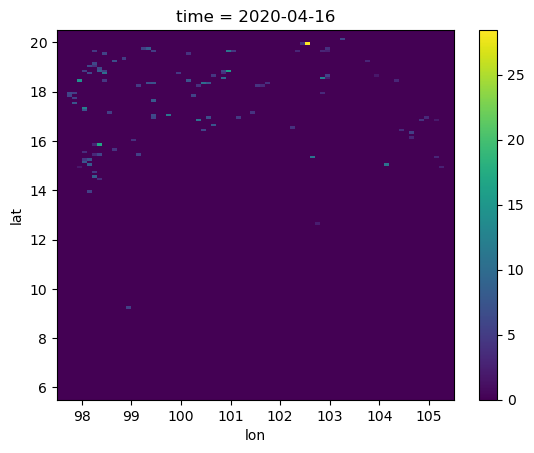

In [8]:
frp_combined.sel(time='2020-04-16').sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).plot() #เหมือนs3aวัดไฟตอนเช้า มีเชียงใหม่ไหม้ กทม ดับ พอ s3b วัดไฟตอนบ่าย กทมไหม้ เชียงใหม่ดับ เพราะงั้นค่าเฉลี่ยเลยเพิ่มขึ้น สังเกตจากวันที่ 2020-04-16 s3aได้ 0.027 s3b ได้ 0.029 เฉลี่ยได้ 0.051

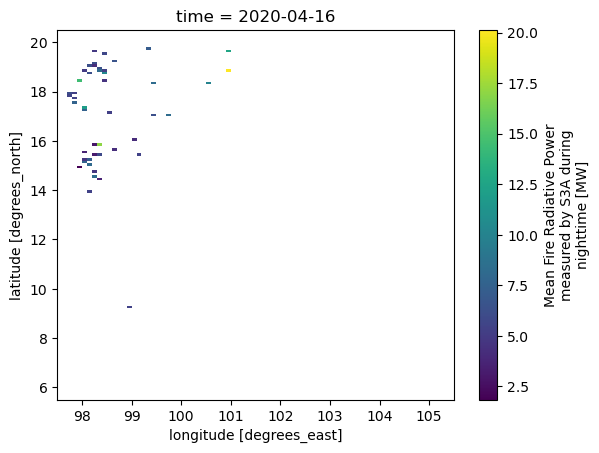

In [9]:
frps3a.sel(time='2020-04-16').sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).plot()

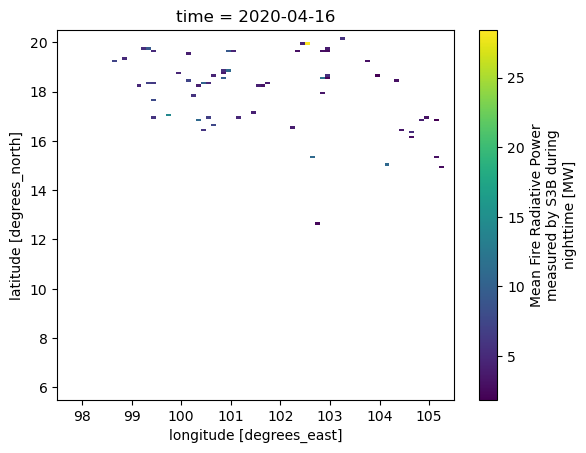

In [10]:
frps3b.sel(time='2020-04-16').sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).plot()

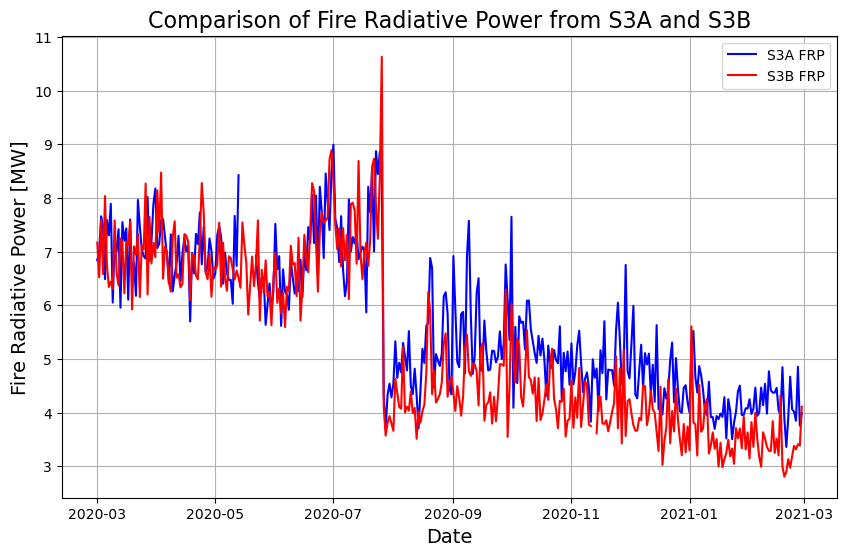

In [11]:
# Assume frps3a and frps3b are DataArrays from S3A and S3B, respectively

# Plotting FRP from S3A and S3B
plt.figure(figsize=(10, 6))
plt.plot(frps3a['time'], frps3a.mean(dim=['lat', 'lon']), label='S3A FRP', color='blue')
plt.plot(frps3b['time'], frps3b.mean(dim=['lat', 'lon']), label='S3B FRP', color='red')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Fire Radiative Power [MW]', fontsize=14)
plt.title('Comparison of Fire Radiative Power from S3A and S3B', fontsize=16)
plt.legend()
plt.grid(True)
plt.savefig('Comparison of Sentinel A B.png')
plt.show()

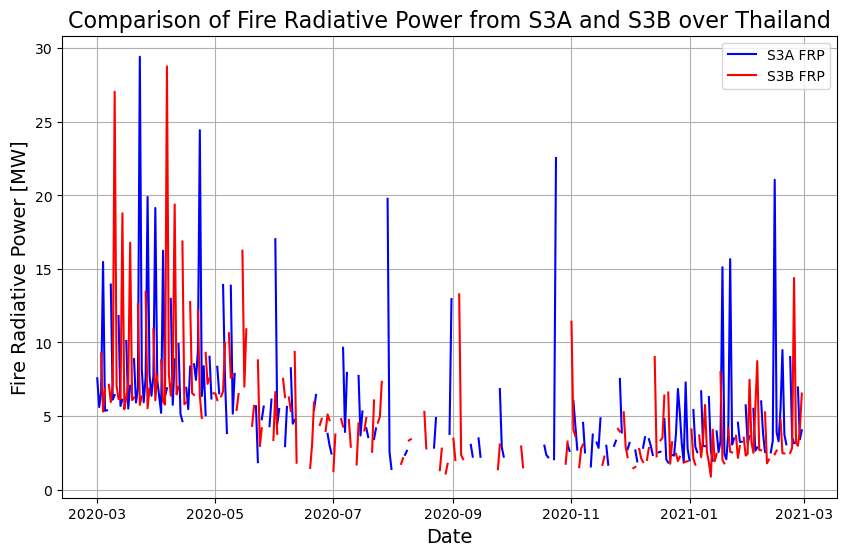

In [12]:
# Assume frps3a and frps3b are DataArrays from S3A and S3B, respectively

# Plotting FRP from S3A and S3B
plt.figure(figsize=(10, 6))
plt.plot(frps3a['time'], frps3a.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).mean(dim=['lat', 'lon']), label='S3A FRP', color='blue')
plt.plot(frps3b['time'], frps3b.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).mean(dim=['lat', 'lon']), label='S3B FRP', color='red')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Fire Radiative Power [MW]', fontsize=14)
plt.title('Comparison of Fire Radiative Power from S3A and S3B over Thailand', fontsize=16)
plt.legend()
plt.grid(True)
plt.savefig('Comparison of Sentinel A B TH.png')
plt.show()

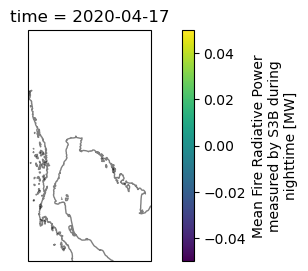

In [13]:
import cartopy.crs as ccrs
fig = plt.figure(figsize=(8,3))
ax = fig.add_subplot(projection=ccrs.PlateCarree())

ax.coastlines(color='black', alpha=0.5)
subset_frps3b.sel(time='2020-04-17').plot(ax=ax, cmap='viridis')

In [ ]:
# Align the datasets on their time coordinates
mean_fwi, mean_frp = xr.align(mean_fwi, mean_frp, join='inner')

# Extract the values as numpy arrays
mean_fwi_values = mean_fwi['fwi'].values
mean_frp_values = mean_frp.values  # Assuming this is already a DataArray

# Align the datasets on their time coordinates
mean_ffmc, mean_fire = xr.align(mean_ffmc, mean_fire, join='inner')

# Extract the values as numpy arrays
mean_ffmc_values = mean_ffmc['ffmc'].values
mean_fire_values = mean_fire.values  # Assuming this is already a DataArray


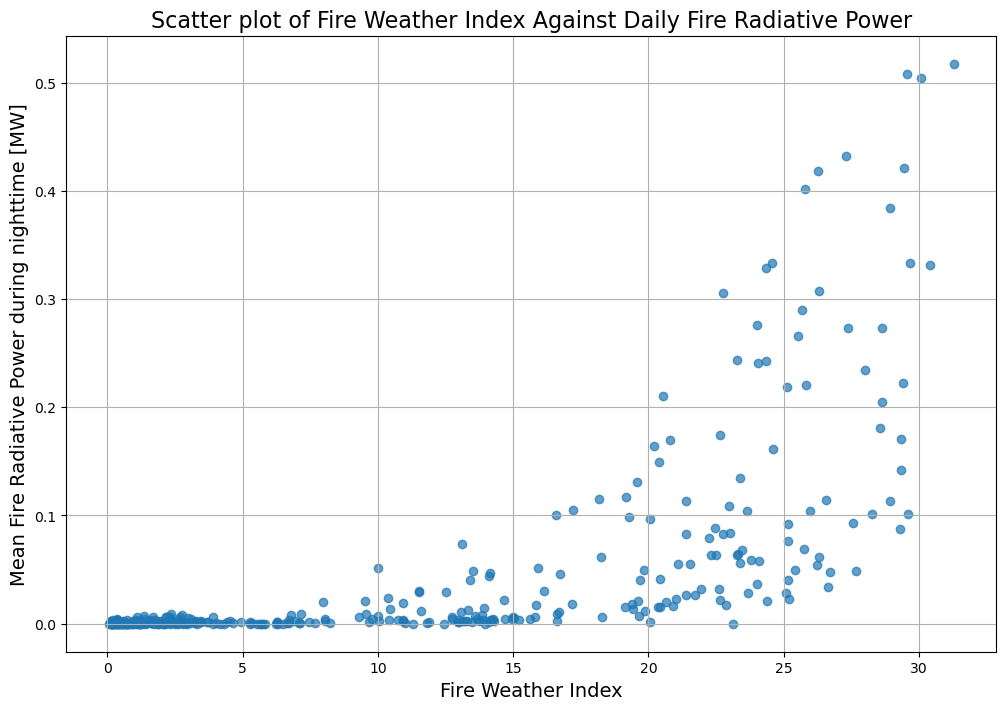

In [15]:
# Compute correlation coefficient
#correlation = np.corrcoef(mean_fwi_values, mean_frp_values)[0, 1]

# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(mean_fwi_values, mean_frp_values, alpha=0.7)

plt.xlabel('Fire Weather Index', fontsize=14)
plt.ylabel('Mean Fire Radiative Power during nighttime [MW]', fontsize=14)
plt.title(f'Scatter plot of Fire Weather Index Against Daily Fire Radiative Power', fontsize=16) # correlation:.2f

# Adding a grid
plt.grid(True)
plt.savefig('Scatter plot of Fire Weather Index Against Mean Fire Radiative Power.png')
plt.show()

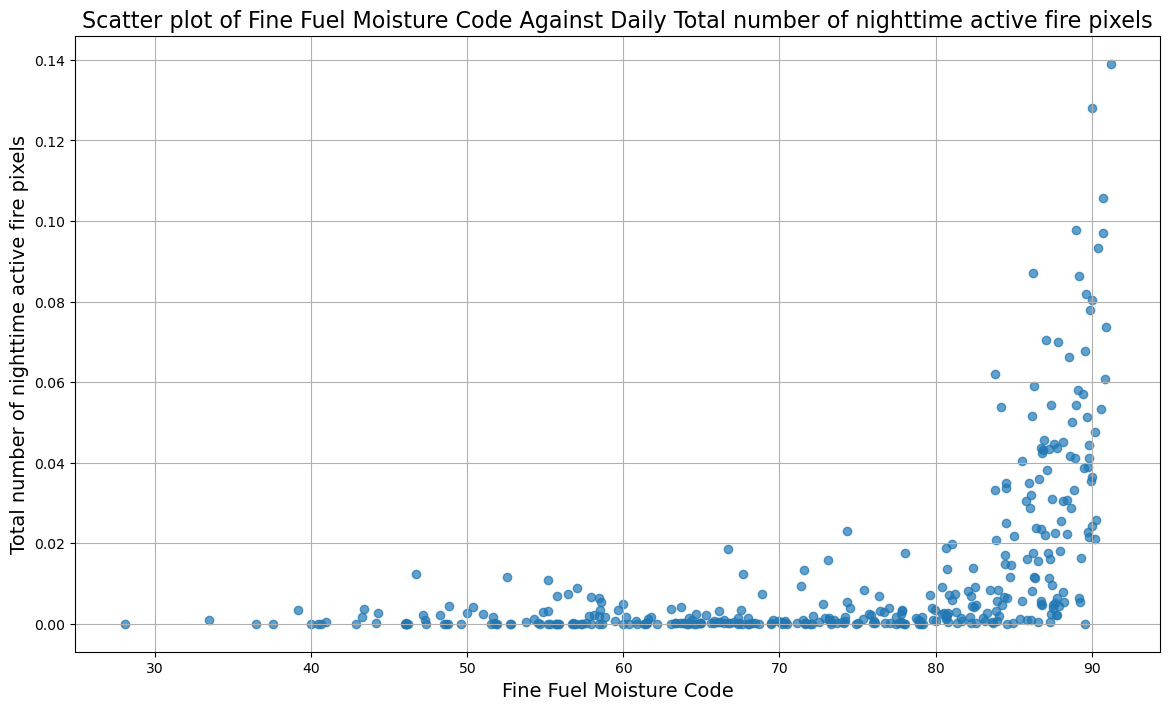

In [16]:
# Compute correlation coefficient
correlation = np.corrcoef(mean_ffmc_values, mean_fire_values)[0, 1]

# Plotting
plt.figure(figsize=(14, 8))
plt.scatter(mean_ffmc_values, mean_fire_values, alpha=0.7)

plt.xlabel('Fine Fuel Moisture Code', fontsize=14)
plt.ylabel('Total number of nighttime active fire pixels', fontsize=14)
plt.title(f'Scatter plot of Fine Fuel Moisture Code Against Daily Total number of nighttime active fire pixels', fontsize=16) #nCorrelation: {correlation:.2f}

# Adding a grid
plt.grid(True)
plt.savefig('3.png')
plt.show()

In [ ]:
def model_exponential(t, A, B, C):
    return A * np.exp(B * t + C)

params_exp = {'A': 3.8e-14, 'B': 0.31, 'C': 21}  # Parameter guess for exponential
paramnames_exp = ['A', 'B', 'C']
param_labels_exp = [r'$A$', r'$B$', r'$C$']

xaxis = np.arange(0,31, 0.2)

In [ ]:
# Plotting
plt.figure(figsize=(14, 8))
plt.plot(xaxis , model_exponential(xaxis , params_exp['A'], params_exp['B'], params_exp['C']), '--', label='Model', color='red')  # Different line style for clarity
plt.scatter(mean_fwi_values, mean_frp_values, alpha=0.7)
plt.xlabel('Fire Weather Index', fontsize=14)
plt.ylabel('Fire Radiative Power', fontsize=14)
plt.title(f'Model', fontsize=16) #nCorrelation: {correlation:.2f}

# Adding a grid
plt.grid(True)
plt.show()

In [5]:
#calculated yerr
#yerr = mean_uncfrp for frp only

In [ ]:
def log_prior(theta):
    # Uniform prior bounds
    A, B, C = theta
    if 0.0 < A < 1.0 and 0.0 < B < 1.0 and -100.0 < C < 100.0:
        return 0.0
    return -np.inf

def log_likelihood(theta, t, y, yerr):
    #yerr is frp_uncertainty which is calculated from s3a and s3b
    # Calculate the likelihood as a sum of normal log PDFs
    A, B, C = theta
    model = A * np.exp(B * t) + C
    yerr = np.where(yerr <= 0, 1e-6, yerr)
    sigma2 = yerr ** 2
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

def log_probability(theta, t, y, yerr):
    # Combine prior and likelihood for posterior probability
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, y, yerr)

In [ ]:
from scipy.optimize import minimize

np.random.seed(42)
nll = lambda *args: -log_likelihood(*args)
initial = np.array([params_exp['A'], params_exp['B'], params_exp['C']]) + 0.1 * np.random.randn(3)
soln = minimize(nll, initial, args=(mean_fwi_values, mean_frp_values, mean_uncfrp), method='L-BFGS-B')
A, B, C = soln.x
print(soln.x)

In [ ]:
xaxis2= np.arange(0,35, 0.02)
# plot the data with the initial guess together and tuning the initial guess to be a reasonable fit.
plt.scatter(mean_fwi_values, mean_frp_values, alpha=0.7)
plt.plot(xaxis2 , model(xaxis2 , params['A'], params['B'], params['C']), '--', label='Model')  # Different line style for clarity
plt.plot(xaxis2 , model(xaxis2 , *soln.x), '--', label='Best fit value')
# Add labels and legend
plt.xlabel(' ')
plt.ylabel(' ')
plt.legend()

# Show the plot
plt.show()

In [ ]:
# Do everything yourself.
import emcee

pos = soln.x + 1e-4 * np.random.randn(32, 3)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(mean_fwi_values, mean_frp_values, mean_uncfrp)
)
sampler.run_mcmc(pos, 5000, progress=True);

In [ ]:
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["A", "B", "C"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [ ]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)
print(samples)

In [ ]:
# look at trace plots

chains = np.array([samples[:,i,:] for i in range(32)])

plt.rcParams['figure.figsize'] = (16.0, 12.0)
fig, ax = plt.subplots(len(param_labels), 1);
cr.plot_traces(chains, ax, labels=param_labels, Line2D_kwargs={'markersize':1.0})

In [ ]:
# remove burn-in and look again, in case detail was lacking with the previous scale

burn = 200
chains = [chain[burn:,:] for chain in chains]
fig, ax = plt.subplots(len(param_labels), 1);
cr.plot_traces(chains, ax, labels=param_labels, Line2D_kwargs={'markersize':1.0})

In [ ]:
#this code give us nan in correlation we wont use it and will adjust it in below line
# Align the datasets on their time coordinates
mean_fwi, mean_frp = xr.align(mean_fwi, mean_frp, join='inner')

# Extract the values as numpy arrays
mean_fwi_values = mean_fwi['fwi'].values
mean_frp_values = mean_frp.values  # Assuming this is already a DataArray

# Compute correlation coefficient
correlation = np.corrcoef(mean_fwi_values, np.log10(mean_frp_values))[0, 1]

# Plotting
plt.figure(figsize=(14, 8))
plt.scatter(mean_fwi_values, np.log10(mean_frp_values), alpha=0.7)

plt.xlabel('Fire Weather Index', fontsize=14)
plt.ylabel('Mean Fire Radiative Power during nighttime [MW]', fontsize=14)
plt.title(f'Scatter plot of Fire Weather Index Against Mean Fire Radiative Power\nCorrelation: {correlation:.2f}', fontsize=16)

# Adding a grid
plt.grid(True)
plt.show()

In [ ]:
# Align the datasets on their time coordinates
mean_fwi, mean_frp = xr.align(mean_fwi, mean_frp, join='inner')

# Extract the values as numpy arrays
mean_fwi_values = mean_fwi['fwi'].values
mean_frp_values = mean_frp.values  # Assuming this is already a DataArray

# Filter out NaN values and non-positive values
valid_indices = ~np.isnan(mean_fwi_values) & ~np.isnan(mean_frp_values) & (mean_frp_values > 0) #cannot be 0 or negative one
filtered_fwi_values = mean_fwi_values[valid_indices]
filtered_frp_values = mean_frp_values[valid_indices]

# Compute correlation coefficient
correlation = np.corrcoef(filtered_fwi_values, np.log10(filtered_frp_values))[0, 1]

# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(filtered_fwi_values, np.log10(filtered_frp_values), alpha=0.7)

plt.xlabel('Fire Weather Index (FWI)', fontsize=14)
plt.ylabel('log10(Mean Fire Radiative Power during nighttime [MW])', fontsize=14)
plt.title(f'Scatter plot of Fire Weather Index Against log10(Mean Fire Radiative Power)\nCorrelation: {correlation:.2f}', fontsize=16)

# Adding a grid
plt.grid(True)
plt.savefig('Scatter plot of FWI vs. Mean FRP.png')
plt.show()


In [ ]:
#this code also nan 
# Align the datasets on their time coordinates
mean_ffmc, mean_fire = xr.align(mean_ffmc, mean_fire, join='inner')

# Extract the values as numpy arrays
mean_ffmc_values = mean_ffmc['ffmc'].values
mean_fire_values = mean_fire.values  # Assuming this is already a DataArray

# Compute correlation coefficient
correlation = np.corrcoef(mean_ffmc_values, np.log10(mean_fire_values))[0, 1]

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(mean_ffmc_values, np.log10(mean_fire_values), alpha=0.7)

plt.xlabel('Fine Fuel Moisture Code (FFMC)', fontsize=14)
plt.ylabel('Total number of nighttime active fire pixels', fontsize=14)
plt.title(f'Scatter plot of Total number of nighttime active fire pixels Against Fine Fuel Moisture Code', fontsize=14)

# Adding a grid
plt.grid(True)

plt.show()

In [ ]:
# Align the datasets on their time coordinates
mean_ffmc, sum_fire = xr.align(mean_ffmc, sum_fire, join='inner')

# Extract the values as numpy arrays
mean_ffmc_values = mean_ffmc['ffmc'].values
sum_fire_values = sum_fire.values  # Assuming this is already a DataArray

# Filter out NaN values and non-positive values
valid_indices = ~np.isnan(mean_ffmc_values) & ~np.isnan(sum_fire_values) & (sum_fire_values > 0) #cannot be 0 or negative one
filtered_ffmc_values = mean_ffmc_values[valid_indices]
filtered_fire_values = sum_fire_values[valid_indices]

# Compute correlation coefficient
correlation = np.corrcoef(filtered_ffmc_values, np.log10(filtered_fire_values))[0, 1]

# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(filtered_ffmc_values, np.log10(filtered_fire_values), alpha=0.7)

plt.xlabel('Fine Fuel Moisture Code', fontsize=14)
plt.ylabel('log10(Total number of nighttime active fire pixels)', fontsize=14)
plt.title(f'Scatter plot of Fine Fuel Moisture Code vs. log10(Total number of nighttime active fire pixels) \nCorrelation: {correlation:.2f}', fontsize=16)

# Adding a grid
plt.grid(True)
plt.savefig('Scatter plot of Fine Fuel Moisture Code vs. log10(Total number of nighttime active fire pixels).png')
plt.show()


In [ ]:
from scipy.stats import linregress

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(filtered_ffmc_values, np.log10(filtered_fire_values))
y_pred = slope * filtered_ffmc_values + intercept

# Calculate R-squared
r_squared = r_value ** 2

# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(filtered_ffmc_values, np.log10(filtered_fire_values), alpha=0.7, label='Data')

# Plot the regression line
plt.plot(filtered_ffmc_values, y_pred, color='red', label=f'Regression line: y = {slope:.4f}x + {intercept:.4f}')

plt.xlabel('Fine Fuel Moisture Code', fontsize=14)
plt.ylabel('log10(Total number of nighttime active fire pixels)', fontsize=14)
plt.title(f'Scatter plot of Fine Fuel Moisture Code vs. log10(Total number of nighttime active fire pixels) \nCorrelation: {correlation:.4f}, $R^2$: {r_squared:.4f}', fontsize=16)

# Adding a grid and legend
plt.grid(True)
plt.legend()
plt.savefig('Scatter plot of Fine Fuel Moisture Code vs. log10(Total number of nighttime active fire pixels) with r.png')
plt.show()

In [ ]:
# Assuming mean_ffmc and mean_fire are aligned properly
# Align the datasets on their time coordinates
mean_fwi, mean_frp = xr.align(mean_fwi, mean_frp, join='inner')

# Extract the values as numpy arrays
mean_fwi_values = mean_fwi['fwi'].values
mean_frp_values = mean_frp.values

# Filter out NaN values and non-positive values
valid_indices = ~np.isnan(mean_fwi_values) & ~np.isnan(mean_frp_values) & (mean_frp_values > 0)
filtered_fwi_values = mean_fwi_values[valid_indices]
filtered_frp_values = mean_frp_values[valid_indices]

# Compute correlation coefficient
correlation = np.corrcoef(filtered_fwi_values, np.log10(filtered_frp_values))[0, 1]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(filtered_fwi_values, np.log10(filtered_frp_values))
y_pred = slope * filtered_fwi_values + intercept

# Calculate R-squared
r_squared = r_value ** 2

# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(filtered_fwi_values, np.log10(filtered_frp_values), alpha=0.7, label='Data')

# Plot the regression line
plt.plot(filtered_fwi_values, y_pred, color='red', label=f'Regression line: y = {slope:.4f}x + {intercept:.4f}')

plt.xlabel('Fire Weather Index', fontsize=14)
plt.ylabel('log10(Fire radiative power)', fontsize=14)
plt.title(f'Scatter plot of Fire Weather Index vs. log10(Fire radiative power) \nCorrelation: {correlation:.4f}, $R^2$: {r_squared:.4f}', fontsize=16)

# Adding a grid and legend
plt.grid(True)
plt.legend()
plt.savefig('Scatter plot of FWI vs. log10(Fire radiative power with R.png')
plt.show()

In [ ]:
# Define the seasons
warm_dry = (mean_ffmc['time.month'] >= 2) & (mean_ffmc['time.month'] < 5)
rain = (mean_ffmc['time.month'] >= 5) & (mean_ffmc['time.month'] < 10)
cool_dry = (mean_ffmc['time.month'] >= 10) | (mean_ffmc['time.month'] < 2)

# Filter data by season
mean_ffmc_warm_dry = mean_ffmc.where(warm_dry, drop=True)
mean_ffmc_rain = mean_ffmc.where(rain, drop=True)
mean_ffmc_cool_dry = mean_ffmc.where(cool_dry, drop=True)

mean_fwi_warm_dry = mean_fwi.where(warm_dry, drop=True)
mean_fwi_rain = mean_fwi.where(rain, drop=True)
mean_fwi_cool_dry = mean_fwi.where(cool_dry, drop=True)

mean_frp_warm_dry = mean_frp.where(warm_dry, drop=True)
mean_frp_rain = mean_frp.where(rain, drop=True)
mean_frp_cool_dry = mean_frp.where(cool_dry, drop=True)

sum_fire_warm_dry = sum_fire.where(warm_dry, drop=True)
sum_fire_rain = sum_fire.where(rain, drop=True)
sum_fire_cool_dry = sum_fire.where(cool_dry, drop=True)

# Output the mean values for each season
print("Warm Dry Season (Mid Feb - Mid May):")
print(mean_ffmc_warm_dry.mean(dim='time'))
print(mean_fwi_warm_dry.mean(dim='time'))
print(mean_frp_warm_dry.mean(dim='time'))
print(sum_fire_warm_dry.mean(dim='time'))

print("\nRain Season (Mid May - Mid Oct):")
print(mean_ffmc_rain.mean(dim='time'))
print(mean_fwi_rain.mean(dim='time'))
print(mean_frp_rain.mean(dim='time'))
print(sum_fire_rain.mean(dim='time'))

print("\nCool Dry Season (Mid Oct - Mid Feb):")
print(mean_ffmc_cool_dry.mean(dim='time'))
print(mean_fwi_cool_dry.mean(dim='time'))
print(mean_frp_cool_dry.mean(dim='time'))
print(sum_fire_cool_dry.mean(dim='time'))

In [ ]:
# Assuming mean_ffmc and mean_fire are aligned properly
# Align the datasets on their time coordinates
mean_fwi_warm_dry, mean_frp_warm_dry = xr.align(mean_fwi_warm_dry, mean_frp_warm_dry, join='inner')

# Extract the values as numpy arrays
mean_fwi_warm_dry_values = mean_fwi_warm_dry['fwi'].values
mean_frp_warm_dry_values = mean_frp_warm_dry.values

# Filter out NaN values and non-positive values
valid_indices = ~np.isnan(mean_fwi_warm_dry_values) & ~np.isnan(mean_frp_warm_dry_values) & (mean_frp_warm_dry_values > 0)
filtered_fwi_warm_dry_values = mean_fwi_warm_dry_values[valid_indices]
filtered_frp_warm_dry_values = mean_frp_warm_dry_values[valid_indices]

# Compute correlation coefficient
correlation = np.corrcoef(filtered_fwi_warm_dry_values, np.log10(filtered_frp_warm_dry_values))[0, 1]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(filtered_fwi_warm_dry_values, np.log10(filtered_frp_warm_dry_values))
y_pred = slope * filtered_fwi_warm_dry_values + intercept

# Calculate R-squared
r_squared = r_value ** 2

# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(filtered_fwi_warm_dry_values, np.log10(filtered_frp_warm_dry_values), alpha=0.7, label='Data')

# Plot the regression line
plt.plot(filtered_fwi_warm_dry_values, y_pred, color='red', label=f'Regression line: y = {slope:.4f}x + {intercept:.4f}')

plt.xlabel('Fire Weather Index', fontsize=14)
plt.ylabel('log10(Fire radiative power)', fontsize=14)
plt.title(f'Scatter plot of Fire Weather Index vs. log10(Fire radiative power) warm dry season\nCorrelation: {correlation:.4f}, $R^2$: {r_squared:.4f}', fontsize=16)

# Adding a grid and legend
plt.grid(True)
plt.legend(fontsize=12)
plt.savefig('Scatter plot of Fire Weather Index vs. log10(Fire radiative power) warm dry season.png')
plt.show()

In [ ]:
# Assuming mean_ffmc and mean_fire are aligned properly
# Align the datasets on their time coordinates
mean_fwi_rain, mean_frp_rain = xr.align(mean_fwi_rain, mean_frp_rain, join='inner')

# Extract the values as numpy arrays
mean_fwi_rain_values = mean_fwi_rain['fwi'].values
mean_frp_rain_values = mean_frp_rain.values

# Filter out NaN values and non-positive values
valid_indices = ~np.isnan(mean_fwi_rain_values) & ~np.isnan(mean_frp_rain_values) & (mean_frp_rain_values > 0)
filtered_fwi_rain_values = mean_fwi_rain_values[valid_indices]
filtered_frp_rain_values = mean_frp_rain_values[valid_indices]

# Compute correlation coefficient
correlation = np.corrcoef(filtered_fwi_rain_values, np.log10(filtered_frp_rain_values))[0, 1]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(filtered_fwi_rain_values, np.log10(filtered_frp_rain_values))
y_pred = slope * filtered_fwi_rain_values + intercept

# Calculate R-squared
r_squared = r_value ** 2

# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(filtered_fwi_rain_values, np.log10(filtered_frp_rain_values), alpha=0.7, label='Data')

# Plot the regression line
plt.plot(filtered_fwi_rain_values, y_pred, color='red', label=f'Regression line: y = {slope:.4f}x + {intercept:.4f}')

plt.xlabel('Fire Weather Index', fontsize=14)
plt.ylabel('log10(Fire radiative power)', fontsize=14)
plt.title(f'Scatter plot of Fire Weather Index vs. log10(Fire radiative power) rain season\nCorrelation: {correlation:.4f}, $R^2$: {r_squared:.4f}', fontsize=16)

# Adding a grid and legend
plt.grid(True)
plt.legend(fontsize=12)
plt.savefig('Scatter plot of Fire Weather Index vs. log10(Fire radiative power) rain season.png')
plt.show()

In [ ]:
# Assuming mean_ffmc and mean_fire are aligned properly
# Align the datasets on their time coordinates
mean_fwi_cool_dry, mean_frp_cool_dry = xr.align(mean_fwi_cool_dry, mean_frp_cool_dry, join='inner')

# Extract the values as numpy arrays
mean_fwi_cool_dry_values = mean_fwi_cool_dry['fwi'].values
mean_frp_cool_dry_values = mean_frp_cool_dry.values

# Filter out NaN values and non-positive values
valid_indices = ~np.isnan(mean_fwi_cool_dry_values) & ~np.isnan(mean_frp_cool_dry_values) & (mean_frp_cool_dry_values > 0)
filtered_fwi_cool_dry_values = mean_fwi_cool_dry_values[valid_indices]
filtered_frp_cool_dry_values = mean_frp_cool_dry_values[valid_indices]

# Compute correlation coefficient
correlation = np.corrcoef(filtered_fwi_cool_dry_values, np.log10(filtered_frp_cool_dry_values))[0, 1]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(filtered_fwi_cool_dry_values, np.log10(filtered_frp_cool_dry_values))
y_pred = slope * filtered_fwi_cool_dry_values + intercept  # Adjusted to match filtered_fwi_cool_dry_values

# Calculate R-squared
r_squared = r_value ** 2

# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(filtered_fwi_cool_dry_values, np.log10(filtered_frp_cool_dry_values), alpha=0.7, label='Data')

# Plot the regression line
plt.plot(filtered_fwi_cool_dry_values, y_pred, color='red', label=f'Regression line: y = {slope:.4f}x + {intercept:.4f}')

plt.xlabel('Fire Weather Index', fontsize=14)
plt.ylabel('log10(Fire radiative power)', fontsize=14)
plt.title(f'Scatter plot of Fire Weather Index vs. log10(Fire radiative power) Cool dry season \nCorrelation: {correlation:.4f}, $R^2$: {r_squared:.4f}', fontsize=16)

# Adding a grid and legend
plt.grid(True)
plt.legend(fontsize=12)
plt.savefig('Scatter plot of Fire Weather Index vs. log10(Fire radiative power) cool dry season.png')
plt.show()


In [ ]:
from scipy.stats import linregress

# Assuming mean_ffmc and mean_fire are aligned properly
# Align the datasets on their time coordinates
mean_ffmc_warm_dry, mean_fire_warm_dry = xr.align(mean_ffmc_warm_dry, mean_fire_warm_dry, join='inner')

# Extract the values as numpy arrays
mean_ffmc_warm_dry_values = mean_ffmc_warm_dry['ffmc'].values
mean_fire_warm_dry_values = mean_fire_warm_dry.values

# Filter out NaN values and non-positive values
valid_indices = ~np.isnan(mean_ffmc_warm_dry_values) & ~np.isnan(mean_fire_warm_dry_values) & (mean_fire_warm_dry_values > 0)
filtered_ffmc_warm_dry_values = mean_ffmc_warm_dry_values[valid_indices]
filtered_fire_warm_dry_values = mean_fire_warm_dry_values[valid_indices]

# Compute correlation coefficient
correlation = np.corrcoef(filtered_ffmc_warm_dry_values, np.log10(filtered_fire_warm_dry_values))[0, 1]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(filtered_ffmc_warm_dry_values, np.log10(filtered_fire_warm_dry_values))
y_pred = slope * filtered_ffmc_warm_dry_values + intercept

# Calculate R-squared
r_squared = r_value ** 2

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(filtered_ffmc_warm_dry_values, np.log10(filtered_fire_warm_dry_values), alpha=0.7, label='Data')

# Plot the regression line
plt.plot(filtered_ffmc_warm_dry_values, y_pred, color='red', label=f'Regression line: y = {slope:.4f}x + {intercept:.4f}')

plt.xlabel('Fine Fuel Moisture Code (FFMC)')
plt.ylabel('log10(Total number of nighttime active fire pixels)')
plt.title(f'Scatter plot of FFMC vs. log10(Mean FIRE) Warm Dry Season\nCorrelation: {correlation:.4f}, $R^2$: {r_squared:.4f}')

# Adding a grid and legend
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# Assuming mean_ffmc and mean_fire are aligned properly
# Align the datasets on their time coordinates
mean_ffmc_rain, mean_fire_rain = xr.align(mean_ffmc_rain, mean_fire_rain, join='inner')

# Extract the values as numpy arrays
mean_ffmc_rain_values = mean_ffmc_rain['ffmc'].values
mean_fire_rain_values = mean_fire_rain.values

# Filter out NaN values and non-positive values
valid_indices = ~np.isnan(mean_ffmc_rain_values) & ~np.isnan(mean_fire_rain_values) & (mean_fire_rain_values > 0)
filtered_ffmc_rain_values = mean_ffmc_rain_values[valid_indices]
filtered_fire_rain_values = mean_fire_rain_values[valid_indices]

# Compute correlation coefficient
correlation = np.corrcoef(filtered_ffmc_rain_values, np.log10(filtered_fire_rain_values))[0, 1]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(filtered_ffmc_rain_values, np.log10(filtered_fire_rain_values))
y_pred = slope * filtered_ffmc_rain_values + intercept

# Calculate R-squared
r_squared = r_value ** 2

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(filtered_ffmc_rain_values, np.log10(filtered_fire_rain_values), alpha=0.7, label='Data')

# Plot the regression line
plt.plot(filtered_ffmc_rain_values, y_pred, color='red', label=f'Regression line: y = {slope:.4f}x + {intercept:.4f}')

plt.xlabel('Fine Fuel Moisture Code (FFMC)')
plt.ylabel('log10(Total number of nighttime active fire pixels)')
plt.title(f'Scatter plot of FFMC vs. log10(Mean FIRE) Rain Season\nCorrelation: {correlation:.4f}, $R^2$: {r_squared:.4f}')

# Adding a grid and legend
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# Assuming mean_ffmc and mean_fire are aligned properly
# Align the datasets on their time coordinates
mean_ffmc_cool_dry, mean_fire_cool_dry = xr.align(mean_ffmc_cool_dry, mean_fire_cool_dry, join='inner')

# Extract the values as numpy arrays
mean_ffmc_cool_dry_values = mean_ffmc_cool_dry['ffmc'].values
mean_fire_cool_dry_values = mean_fire_cool_dry.values

# Filter out NaN values and non-positive values
valid_indices = ~np.isnan(mean_ffmc_cool_dry_values) & ~np.isnan(mean_fire_cool_dry_values) & (mean_fire_cool_dry_values > 0)
filtered_ffmc_cool_dry_values = mean_ffmc_cool_dry_values[valid_indices]
filtered_fire_cool_dry_values = mean_fire_cool_dry_values[valid_indices]

# Compute correlation coefficient
correlation = np.corrcoef(filtered_ffmc_cool_dry_values, np.log10(filtered_fire_cool_dry_values))[0, 1]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(filtered_ffmc_cool_dry_values, np.log10(filtered_fire_cool_dry_values))
y_pred = slope * filtered_ffmc_cool_dry_values + intercept

# Calculate R-squared
r_squared = r_value ** 2

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(filtered_ffmc_cool_dry_values, np.log10(filtered_fire_cool_dry_values), alpha=0.7, label='Data')

# Plot the regression line
plt.plot(filtered_ffmc_cool_dry_values, y_pred, color='red', label=f'Regression line: y = {slope:.4f}x + {intercept:.4f}')

plt.xlabel('Fine Fuel Moisture Code (FFMC)')
plt.ylabel('log10(Total number of nighttime active fire pixels)')
plt.title(f'Scatter plot of FFMC vs. log10(Mean FIRE) Cool Dry Season\nCorrelation: {correlation:.4f}, $R^2$: {r_squared:.4f}')

# Adding a grid and legend
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# Align the datasets on their time coordinates for all seasons
mean_fwi_warm_dry, mean_frp_warm_dry = xr.align(mean_fwi_warm_dry, mean_frp_warm_dry, join='inner')
mean_fwi_rain, mean_frp_rain = xr.align(mean_fwi_rain, mean_frp_rain, join='inner')
mean_fwi_cool_dry, mean_frp_cool_dry = xr.align(mean_fwi_cool_dry, mean_frp_cool_dry, join='inner')

# Function to compute correlation, regression, and plot for a given season
def process_and_plot(fwi, frp, season_name, color):
    # Extract the values as numpy arrays
    fwi_values = fwi['fwi'].values
    frp_values = frp.values

    # Filter out NaN values and non-positive values
    valid_indices = ~np.isnan(fwi_values) & ~np.isnan(frp_values) & (frp_values > 0)
    filtered_fwi_values = fwi_values[valid_indices]
    filtered_frp_values = frp_values[valid_indices]

    # Compute correlation coefficient
    correlation = np.corrcoef(filtered_fwi_values, np.log10(filtered_frp_values))[0, 1]

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(filtered_fwi_values, np.log10(filtered_frp_values))
    y_pred = slope * filtered_fwi_values + intercept

    # Plotting
    plt.scatter(filtered_fwi_values, np.log10(filtered_frp_values), alpha=0.7, label=f'{season_name} (Corr: {correlation:.2f}, $R$: {r_value:.2f})', color=color)
    plt.plot(filtered_fwi_values, y_pred, color=color, linestyle='--')

# Plot all seasons
plt.figure(figsize=(12, 8))

process_and_plot(mean_fwi_warm_dry, mean_frp_warm_dry, "Warm Dry", "red")
process_and_plot(mean_fwi_rain, mean_frp_rain, "Rain", "blue")
process_and_plot(mean_fwi_cool_dry, mean_frp_cool_dry, "Cool Dry", "green")

plt.xlabel('Fire Weather Index (FWI)')
plt.ylabel('log10(Fire Radiative Power)')
plt.title('Scatter plot of FWI vs. log10(FRP) for Different Seasons')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Align the datasets on their time coordinates for all seasons
mean_ffmc_warm_dry, mean_fire_warm_dry = xr.align(mean_ffmc_warm_dry, mean_fire_warm_dry, join='inner')
mean_ffmc_rain, mean_fire_rain = xr.align(mean_ffmc_rain, mean_fire_rain, join='inner')
mean_ffmc_cool_dry, mean_fire_cool_dry = xr.align(mean_ffmc_cool_dry, mean_fire_cool_dry, join='inner')

# Function to compute correlation, regression, and plot for a given season
def process_and_plot(ffmc, fire, season_name, color):
    # Extract the values as numpy arrays
    ffmc_values = ffmc['ffmc'].values
    fire_values = fire.values

    # Filter out NaN values and non-positive values
    valid_indices = ~np.isnan(ffmc_values) & ~np.isnan(fire_values) & (fire_values > 0)
    filtered_ffmc_values = ffmc_values[valid_indices]
    filtered_fire_values = fire_values[valid_indices]

    # Compute correlation coefficient
    correlation = np.corrcoef(filtered_ffmc_values, np.log10(filtered_fire_values))[0, 1]

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(filtered_ffmc_values, np.log10(filtered_fire_values))
    y_pred = slope * filtered_ffmc_values + intercept


    # Plotting
    plt.scatter(filtered_ffmc_values, np.log10(filtered_fire_values), alpha=0.7, label=f'{season_name} (Corr: {correlation:.2f}, $R$: {r_value:.2f})', color=color)
    plt.plot(filtered_ffmc_values, y_pred, color=color, linestyle='--')

# Plot all seasons
plt.figure(figsize=(12, 8))

process_and_plot(mean_ffmc_warm_dry, mean_fire_warm_dry, "Warm Dry", "red")
process_and_plot(mean_ffmc_rain, mean_fire_rain, "Rain", "blue")
process_and_plot(mean_ffmc_cool_dry, mean_fire_cool_dry, "Cool Dry", "green")

plt.xlabel('Fine Fuel Moisture Code (FFMC)')
plt.ylabel('log10(Fire Pixel)')
plt.title('Scatter plot of FFMC vs. log10(Fire Pixel) for Different Seasons')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Assuming mean_ffmc and mean_fire are aligned properly
# Align the datasets on their time coordinates
mean_fwi_warm_dry, mean_frp_warm_dry = xr.align(mean_fwi_warm_dry, mean_frp_warm_dry, join='inner')

# Extract the values as numpy arrays
mean_fwi_warm_dry_values = mean_fwi_warm_dry['fwi'].values
mean_frp_warm_dry_values = mean_frp_warm_dry.values

# Filter out NaN values and non-positive values
valid_indices = ~np.isnan(mean_fwi_warm_dry_values) & ~np.isnan(mean_frp_warm_dry_values) & (mean_frp_warm_dry_values > 0)
filtered_fwi_warm_dry_values = mean_fwi_warm_dry_values[valid_indices]
filtered_frp_warm_dry_values = mean_frp_warm_dry_values[valid_indices]


# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(filtered_fwi_warm_dry_values, filtered_frp_warm_dry_values, alpha=0.7, label='Data')

# Plot the regression line

plt.xlabel('Fire Weather Index', fontsize=14)
plt.ylabel('Fire radiative power', fontsize=14)
plt.title(f'Scatter plot of Fire Weather Index Against Daily Fire radiative power warm dry season', fontsize=16)

# Adding a grid and legend
plt.grid(True)
plt.savefig('Scatter plot of Fire Weather Index vs. Daily Fire radiative power warm dry season.png')
plt.show()

In [ ]:
# Assuming mean_ffmc and mean_fire are aligned properly
# Align the datasets on their time coordinates
mean_fwi_rain, mean_frp_rain = xr.align(mean_fwi_rain, mean_frp_rain, join='inner')

# Extract the values as numpy arrays
mean_fwi_rain_values = mean_fwi_rain['fwi'].values
mean_frp_rain_values = mean_frp_rain.values

# Filter out NaN values and non-positive values
valid_indices = ~np.isnan(mean_fwi_rain_values) & ~np.isnan(mean_frp_rain_values) & (mean_frp_rain_values > 0)
filtered_fwi_rain_values = mean_fwi_rain_values[valid_indices]
filtered_frp_rain_values = mean_frp_rain_values[valid_indices]

# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(filtered_fwi_rain_values, filtered_frp_rain_values, alpha=0.7, label='Data')

plt.xlabel('Fire Weather Index', fontsize=14)
plt.ylabel('Fire radiative power', fontsize=14)
plt.title(f'Scatter plot of Fire Weather Index Against Daily Fire radiative power rain season', fontsize=16)

# Adding a grid and legend
plt.grid(True)
plt.savefig('Scatter plot of Fire Weather Index vs. FRP rain season.png')
plt.show()

In [ ]:
# Assuming mean_ffmc and mean_fire are aligned properly
# Align the datasets on their time coordinates
mean_fwi_cool_dry, mean_frp_cool_dry = xr.align(mean_fwi_cool_dry, mean_frp_cool_dry, join='inner')

# Extract the values as numpy arrays
mean_fwi_cool_dry_values = mean_fwi_cool_dry['fwi'].values
mean_frp_cool_dry_values = mean_frp_cool_dry.values

# Filter out NaN values and non-positive values
valid_indices = ~np.isnan(mean_fwi_cool_dry_values) & ~np.isnan(mean_frp_cool_dry_values) & (mean_frp_cool_dry_values > 0)
filtered_fwi_cool_dry_values = mean_fwi_cool_dry_values[valid_indices]
filtered_frp_cool_dry_values = mean_frp_cool_dry_values[valid_indices]

# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(filtered_fwi_cool_dry_values, filtered_frp_cool_dry_values, alpha=0.7, label='Data')

plt.xlabel('Fire Weather Index', fontsize=14)
plt.ylabel('Fire radiative power', fontsize=14)
plt.title(f'Scatter plot of Fire Weather Index Against Daily Fire radiative power cool dry season', fontsize=16)

# Adding a grid and legend
plt.grid(True)

plt.savefig('Scatter plot of Fire Weather Index vs. Fire radiative power cool dry season.png')
plt.show()


In [ ]:
# Align the datasets on their time coordinates
mean_fwi_cool_dry, mean_frp_cool_dry = xr.align(mean_fwi_cool_dry, mean_frp_cool_dry, join='inner')
mean_fwi_rain, mean_frp_rain = xr.align(mean_fwi_rain, mean_frp_rain, join='inner')
mean_fwi_warm_dry, mean_frp_warm_dry = xr.align(mean_fwi_warm_dry, mean_frp_warm_dry, join='inner')

# Extract the values as numpy arrays and filter valid values
# Cool dry season
mean_fwi_cool_dry_values = mean_fwi_cool_dry['fwi'].values
mean_frp_cool_dry_values = mean_frp_cool_dry.values
valid_indices_cool_dry = ~np.isnan(mean_fwi_cool_dry_values) & ~np.isnan(mean_frp_cool_dry_values) & (mean_frp_cool_dry_values > 0)
filtered_fwi_cool_dry_values = mean_fwi_cool_dry_values[valid_indices_cool_dry]
filtered_frp_cool_dry_values = mean_frp_cool_dry_values[valid_indices_cool_dry]

# Rain season
mean_fwi_rain_values = mean_fwi_rain['fwi'].values
mean_frp_rain_values = mean_frp_rain.values
valid_indices_rain = ~np.isnan(mean_fwi_rain_values) & ~np.isnan(mean_frp_rain_values) & (mean_frp_rain_values > 0)
filtered_fwi_rain_values = mean_fwi_rain_values[valid_indices_rain]
filtered_frp_rain_values = mean_frp_rain_values[valid_indices_rain]

# Warm dry season
mean_fwi_warm_dry_values = mean_fwi_warm_dry['fwi'].values
mean_frp_warm_dry_values = mean_frp_warm_dry.values
valid_indices_warm_dry = ~np.isnan(mean_fwi_warm_dry_values) & ~np.isnan(mean_frp_warm_dry_values) & (mean_frp_warm_dry_values > 0)
filtered_fwi_warm_dry_values = mean_fwi_warm_dry_values[valid_indices_warm_dry]
filtered_frp_warm_dry_values = mean_frp_warm_dry_values[valid_indices_warm_dry]

# Plotting all three seasons
plt.figure(figsize=(12, 8))

# Cool dry season
plt.scatter(filtered_fwi_cool_dry_values, filtered_frp_cool_dry_values, color='blue', alpha=0.7, label='Cool dry season')

# Rain season
plt.scatter(filtered_fwi_rain_values, filtered_frp_rain_values, color='green', alpha=0.7, label='Rain season')

# Warm dry season
plt.scatter(filtered_fwi_warm_dry_values, filtered_frp_warm_dry_values, color='orange', alpha=0.7, label='Warm dry season')

# Labels and title
plt.xlabel('Fire Weather Index', fontsize=14)
plt.ylabel('Fire Radiative Power', fontsize=14)
plt.title('Scatter plot of Fire Weather Index Against Fire Radiative Power for Different Seasons in Thailand', fontsize=16)

# Adding a grid, legend, and showing the plot
plt.grid(True)
plt.legend(fontsize=12)
plt.savefig('Scatter plot of Fire Weather Index vs. Fire radiative power diff season.png')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Define a function to process data, calculate regression, and plot each season
def process_and_plot(season_fwi, season_frp, season_name, color):
    # Align datasets
    season_fwi, season_frp = xr.align(season_fwi, season_frp, join='inner')
    
    # Extract values and filter NaNs and non-positive values
    fwi_values = season_fwi['fwi'].values
    frp_values = season_frp.values
    valid_indices = ~np.isnan(fwi_values) & ~np.isnan(frp_values) & (frp_values > 0)
    filtered_fwi_values = fwi_values[valid_indices]
    filtered_frp_values = frp_values[valid_indices]
    
    # Compute correlation and linear regression on log10 of Fire Radiative Power
    log_frp_values = np.log10(filtered_frp_values)
    correlation = np.corrcoef(filtered_fwi_values, log_frp_values)[0, 1]
    slope, intercept, r_value, p_value, std_err = linregress(filtered_fwi_values, log_frp_values)
    y_pred = slope * filtered_fwi_values + intercept
    r_squared = r_value ** 2

    # Scatter plot and regression line for each season
    plt.scatter(filtered_fwi_values, log_frp_values, color=color, alpha=0.6, label=f'{season_name} season')
    plt.plot(filtered_fwi_values, y_pred, color=color, linestyle='--', label=f'{season_name} regression: y = {slope:.4f}x + {intercept:.4f}\nCorrelation: {correlation:.4f}, $R^2$: {r_squared:.4f}')

# Set up plot
plt.figure(figsize=(12, 8))

# Process and plot each season with a different color
process_and_plot(mean_fwi_cool_dry, mean_frp_cool_dry, 'Cool dry', 'blue')
process_and_plot(mean_fwi_rain, mean_frp_rain, 'Rain', 'green')
process_and_plot(mean_fwi_warm_dry, mean_frp_warm_dry, 'Warm dry', 'orange')

# Labels and title
plt.xlabel('Fire Weather Index', fontsize=14)
plt.ylabel('log10(Fire Radiative Power)', fontsize=14)
plt.title('Scatter plot of Fire Weather Index Against log10(Fire Radiative Power) for Different Seasons in Thailand', fontsize=16)

# Add grid, legend, and save
plt.grid(True)
plt.legend(fontsize=10)
plt.savefig('Scatter plot of Fire Weather Index vs. log10(Fire Radiative Power) for all seasons.png')
plt.show()


In [ ]:
# Align the datasets on their time coordinates
mean_ffmc_cool_dry, sum_fire_cool_dry = xr.align(mean_ffmc_cool_dry, sum_fire_cool_dry, join='inner')
mean_ffmc_rain, sum_fire_rain = xr.align(mean_ffmc_rain, sum_fire_rain, join='inner')
mean_ffmc_warm_dry, sum_fire_warm_dry = xr.align(mean_ffmc_warm_dry, sum_fire_warm_dry, join='inner')

# Extract the values as numpy arrays and filter valid values
# Cool dry season
mean_ffmc_cool_dry_values = mean_ffmc_cool_dry['ffmc'].values
sum_fire_cool_dry_values = sum_fire_cool_dry.values
valid_indices_cool_dry = ~np.isnan(mean_ffmc_cool_dry_values) & ~np.isnan(sum_fire_cool_dry_values) & (sum_fire_cool_dry_values > 0)
filtered_ffmc_cool_dry_values = mean_ffmc_cool_dry_values[valid_indices_cool_dry]
filtered_fire_cool_dry_values = sum_fire_cool_dry_values[valid_indices_cool_dry]

# Rain season
mean_ffmc_rain_values = mean_ffmc_rain['ffmc'].values
sum_fire_rain_values = sum_fire_rain.values
valid_indices_rain = ~np.isnan(mean_ffmc_rain_values) & ~np.isnan(sum_fire_rain_values) & (sum_fire_rain_values > 0)
filtered_ffmc_rain_values = mean_ffmc_rain_values[valid_indices_rain]
filtered_fire_rain_values = sum_fire_rain_values[valid_indices_rain]

# Warm dry season
mean_ffmc_warm_dry_values = mean_ffmc_warm_dry['ffmc'].values
sum_fire_warm_dry_values = sum_fire_warm_dry.values
valid_indices_warm_dry = ~np.isnan(mean_ffmc_warm_dry_values) & ~np.isnan(sum_fire_warm_dry_values) & (sum_fire_warm_dry_values > 0)
filtered_ffmc_warm_dry_values = mean_ffmc_warm_dry_values[valid_indices_warm_dry]
filtered_fire_warm_dry_values = sum_fire_warm_dry_values[valid_indices_warm_dry]

# Plotting all three seasons
plt.figure(figsize=(12, 8))

# Cool dry season
plt.scatter(filtered_ffmc_cool_dry_values, filtered_fire_cool_dry_values, color='blue', alpha=0.7, label='Cool dry season')

# Rain season
plt.scatter(filtered_ffmc_rain_values, filtered_fire_rain_values, color='green', alpha=0.7, label='Rain season')

# Warm dry season
plt.scatter(filtered_ffmc_warm_dry_values, filtered_fire_warm_dry_values, color='orange', alpha=0.7, label='Warm dry season')

# Labels and title
plt.xlabel('Fine Fuel Moisture Code', fontsize=14)
plt.ylabel('Total number of nighttime active fire pixels', fontsize=14)
plt.title('Scatter plot of Fine Fuel Moisture Code Against Daily Total number of nighttime active fire pixels', fontsize=16)

# Adding a grid, legend, and showing the plot
plt.grid(True)
plt.legend(fontsize=12)
plt.savefig('Scatter plot of FFMC vs. Sum of Fire Events for different seasons.png')
plt.show()


In [ ]:
# Define a function to process data, calculate regression, and plot each season
def process_and_plot(season_ffmc, season_fire, season_name, color):
    # Align datasets
    season_ffmc, season_fire = xr.align(season_ffmc, season_fire, join='inner')
    
    # Extract values and filter NaNs and non-positive values
    ffmc_values = season_ffmc['ffmc'].values
    fire_values = season_fire.values
    valid_indices = ~np.isnan(ffmc_values) & ~np.isnan(fire_values) & (fire_values > 0)
    filtered_ffmc_values = ffmc_values[valid_indices]
    filtered_fire_values = fire_values[valid_indices]
    
    # Compute correlation and linear regression on log10 of Fire Radiative Power
    log_fire_values = np.log10(filtered_fire_values)
    correlation = np.corrcoef(filtered_ffmc_values, log_fire_values)[0, 1]
    slope, intercept, r_value, p_value, std_err = linregress(filtered_ffmc_values, log_fire_values)
    y_pred = slope * filtered_ffmc_values + intercept
    r_squared = r_value ** 2

    # Scatter plot and regression line for each season
    plt.scatter(filtered_ffmc_values, log_fire_values, color=color, alpha=0.6, label=f'{season_name} season')
    plt.plot(filtered_ffmc_values, y_pred, color=color, linestyle='--', label=f'{season_name} regression: y = {slope:.4f}x + {intercept:.4f}\nCorrelation: {correlation:.4f}, $R^2$: {r_squared:.4f}')

# Set up plot
plt.figure(figsize=(12, 8))

# Process and plot each season with a different color
process_and_plot(mean_ffmc_cool_dry, mean_fire_cool_dry, 'Cool dry', 'blue')
process_and_plot(mean_ffmc_rain, mean_fire_rain, 'Rain', 'green')
process_and_plot(mean_ffmc_warm_dry, mean_fire_warm_dry, 'Warm dry', 'orange')

# Labels and title
plt.xlabel('Fine Fuel Moisture Code', fontsize=14)
plt.ylabel('log10(Total number of nighttime active fire pixels)', fontsize=14)
plt.title('Scatter plot of Fine Fuel Moisture Code Against log10(Daily Total number of nighttime active fire pixels)', fontsize=16)

# Add grid, legend, and save
plt.grid(True)
plt.legend(fontsize=10)
plt.savefig('Scatter plot of ffmc vs. log10(Fire) for all seasons.png')
plt.show()
